# Imports

In [5]:
import numpy as np 
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_similarity

import pandas as pd
import numpy as np


from sklearn.feature_extraction.text import CountVectorizer
from sklearn.decomposition import LatentDirichletAllocation
from sklearn.metrics.pairwise import cosine_similarity

In [ ]:
# from gensim.models import Word2Vec,LdaMulticore, TfidfModel
# from gensim.models.doc2vec import Doc2Vec, TaggedDocument

# from gensim import corpora
# from gensim.models import LdaModel

# Download Data

In [72]:
movies_df = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/grouplens_movie/movies.csv')
ratings_df = pd.read_csv('/Users/gracefujinaga/MSDS_490/Data/grouplens_movie/ratings.csv')

# EDA

Conduct descriptive analysis on the ratings.csv and movies.csv datasets. Produce any 2 charts to help you understand the dataset. Below is an example:

## Movies

In [73]:
movies_df.head()

,movieId,title,genres
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance
4,5,Father of the Bride Part II (1995),Comedy


In [76]:
movies_df.isna().sum()

movieId                0
title                  0
genres                 0
year                  13
genres_list            0
(no genres listed)     0
Action                 0
Adventure              0
Animation              0
Children               0
Comedy                 0
Crime                  0
Documentary            0
Drama                  0
Fantasy                0
Film-Noir              0
Horror                 0
IMAX                   0
Musical                0
Mystery                0
Romance                0
Sci-Fi                 0
Thriller               0
War                    0
Western                0
dtype: int64

In [75]:
# one hot encode genres
# genre options(from website)Action
genres = [
    "Adventure",
    "Animation",
    "Children's",
    "Comedy",
    "Crime",
    "Documentary",
    "Drama",
    "Fantasy",
    "Film-Noir",
    "Horror",
    "Musical",
    "Mystery",
    "Romance",
    "Sci-Fi",
    "Thriller",
    "War",
    "Western"
]

# one hot encode
movies_df['genres_list'] = movies_df['genres'].str.split('|')
df_exploded = movies_df.explode('genres_list')
genre_dummies = pd.crosstab(df_exploded.index, df_exploded['genres_list'])
movies_df = movies_df.join(genre_dummies)

In [10]:

movies_df.head()

,movieId,title,genres,genres_list,(no genres listed),Action,Adventure,Animation,Children,Comedy,...,Film-Noir,Horror,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,"[Adventure, Animation, Children, Comedy, Fantasy]",0,0,1,1,1,1,...,0,0,0,0,0,0,0,0,0,0
1,2,Jumanji (1995),Adventure|Children|Fantasy,"[Adventure, Children, Fantasy]",0,0,1,0,1,0,...,0,0,0,0,0,0,0,0,0,0
2,3,Grumpier Old Men (1995),Comedy|Romance,"[Comedy, Romance]",0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,"[Comedy, Drama, Romance]",0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
4,5,Father of the Bride Part II (1995),Comedy,[Comedy],0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0


In [74]:
# extract date
movies_df['year'] = movies_df['title'].str.extract(r'\((\d{4})\)', expand=False)
movies_df

,movieId,title,genres,year
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995
2,3,Grumpier Old Men (1995),Comedy|Romance,1995
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995
4,5,Father of the Bride Part II (1995),Comedy,1995
...,...,...,...,...
9737,193581,Black Butler: Book of the Atlantic (2017),Action|Animation|Comedy|Fantasy,2017
9738,193583,No Game No Life: Zero (2017),Animation|Comedy|Fantasy,2017
9739,193585,Flint (2017),Drama,2017
9740,193587,Bungo Stray Dogs: Dead Apple (2018),Action|Animation,2018


## Graph for Movies

In [12]:
movies_by_year = movies_df.groupby('year')['movieId'].count().reset_index(name='count')

In [13]:
print(range(int(movies_by_year['year'].min()), int(movies_by_year['year'].max()) + 1, 10))

range(1902, 2019, 10)


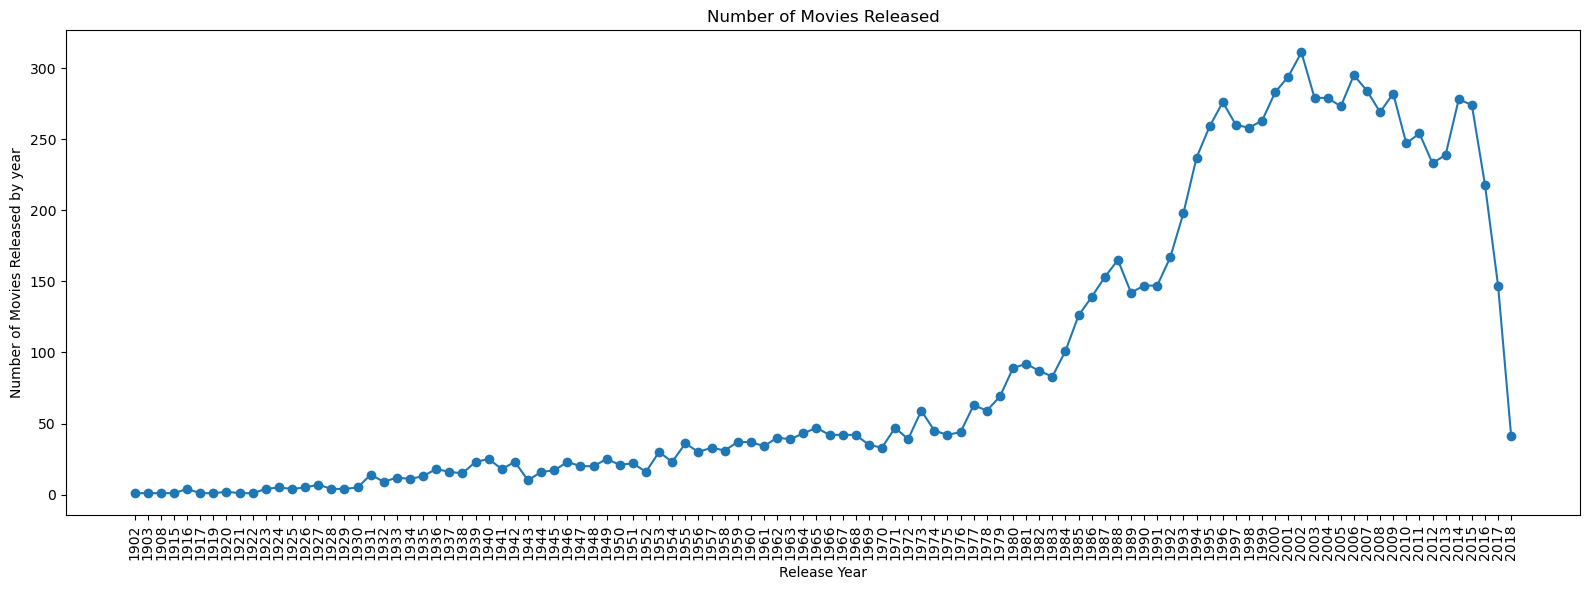

In [14]:
plt.figure(figsize=(16,6))
plt.plot(movies_by_year['year'], movies_by_year['count'], marker='o')

plt.xticks(rotation=90)

plt.xlabel('Release Year')
plt.ylabel('Number of Movies Released by year')
plt.title('Number of Movies Released')
plt.tight_layout()
plt.show()

## Ratings EDA

In [15]:
ratings_df.head()

,userId,movieId,rating,timestamp
0,1,1,4.0,964982703
1,1,3,4.0,964981247
2,1,6,4.0,964982224
3,1,47,5.0,964983815
4,1,50,5.0,964982931


In [16]:
ratings_df.isna().sum()

userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

In [17]:
# convert to helpful date time
ratings_df['datetime'] = pd.to_datetime(ratings_df['timestamp'], unit='s', utc=True)

In [18]:
print(f"number of users: {len(ratings_df['userId'].unique())}")
print(f"number of unique movies: {len(ratings_df['movieId'].unique())}")
print(f"number of total ratings: {len(ratings_df)}")
print(f"timeframe reviewed: {ratings_df['datetime'].min()} to {ratings_df['datetime'].max()}")


number of users: 610
number of unique movies: 9724
number of total ratings: 100836
timeframe reviewed: 1996-03-29 18:36:55+00:00 to 2018-09-24 14:27:30+00:00


## Graph for Ratings

In [19]:
# show ratings per user 
ratings_by_user = ratings_df.groupby('userId')['movieId'].count().reset_index(name='count')
ratings_by_user

,userId,count
0,1,232
1,2,29
2,3,39
3,4,216
4,5,44
...,...,...
605,606,1115
606,607,187
607,608,831
608,609,37


In [20]:
print(ratings_by_user['count'].max())

2698


Text(0, 0.5, 'Frequency')

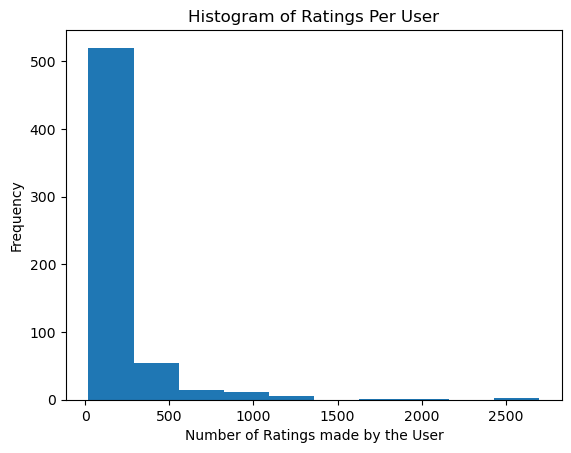

In [21]:
plt.hist(ratings_by_user['count'])
plt.title('Histogram of Ratings Per User')
plt.xlabel('Number of Ratings made by the User')
plt.ylabel('Frequency')

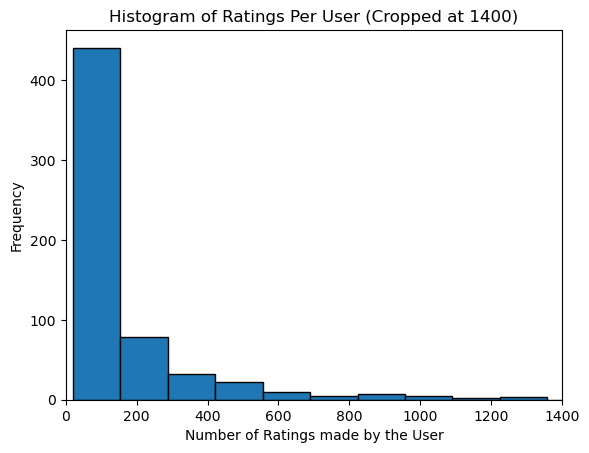

In [22]:
plt.hist(ratings_by_user['count'], edgecolor='black', bins = 20)
plt.xlim(0, 1400)
plt.title('Histogram of Ratings Per User (Cropped at 1400)')
plt.xlabel('Number of Ratings made by the User')
plt.ylabel('Frequency')
plt.show()


# Model

Convert text (genres) to count vectors, use LDA to generate topics and compute cosine similarity function.
Note: in more advanced CBF models, descriptions, tags and other metadata are used but in our assignment, we will just use genres.

In [23]:
movies_df.columns

Index(['movieId', 'title', 'genres', 'genres_list', '(no genres listed)',
       'Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
       'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western',
       'year'],
      dtype='object')

In [162]:
movies_df.head()

,movieId,title,genres,year,genres_list,(no genres listed),Action,Adventure,Animation,Children,...,IMAX,Musical,Mystery,Romance,Sci-Fi,Thriller,War,Western,genre_str,genres_str
0,1,Toy Story (1995),Adventure|Animation|Children|Comedy|Fantasy,1995,"[Adventure, Animation, Children, Comedy, Fantasy]",0,0,1,1,1,...,0,0,0,0,0,0,0,0,Adventure Animation Children Comedy Fantasy,Adventure Animation Children Comedy Fantasy
1,2,Jumanji (1995),Adventure|Children|Fantasy,1995,"[Adventure, Children, Fantasy]",0,0,1,0,1,...,0,0,0,0,0,0,0,0,Adventure Children Fantasy,Adventure Children Fantasy
2,3,Grumpier Old Men (1995),Comedy|Romance,1995,"[Comedy, Romance]",0,0,0,0,0,...,0,0,0,1,0,0,0,0,Comedy Romance,Comedy Romance
3,4,Waiting to Exhale (1995),Comedy|Drama|Romance,1995,"[Comedy, Drama, Romance]",0,0,0,0,0,...,0,0,0,1,0,0,0,0,Comedy Drama Romance,Comedy Drama Romance
4,5,Father of the Bride Part II (1995),Comedy,1995,[Comedy],0,0,0,0,0,...,0,0,0,0,0,0,0,0,Comedy,Comedy


In [169]:
# movies_df[genre_list] is the one hot encoded matrix --> it is also a count vector because each genre is listed only once
genre_list = ['Action', 'Adventure', 'Animation', 'Children', 'Comedy', 'Crime',
       'Documentary', 'Drama', 'Fantasy', 'Film-Noir', 'Horror', 'IMAX',
       'Musical', 'Mystery', 'Romance', 'Sci-Fi', 'Thriller', 'War', 'Western']

# if we wanted to use a vectorizer, could use this for more complex categories or if we used the movie descriptions this would be helpful 
# vectorizer = CountVectorizer()
# genre_matrix = vectorizer.fit_transform(movies_df['genres'])

# LDA from scikit learn library
lda = LatentDirichletAllocation(n_components=15, random_state=42)
#lda_topics = lda.fit_transform(genre_matrix)
lda_topics = lda.fit_transform(movies_df[genre_list])

similarity_matrix = cosine_similarity(lda_topics)

def get_recommendation(movie_name= 'Toy Story (1995)'):
    toy_story_index = movies_df[movies_df['title'] == movie_name].index[0]

    # Get indices of top 5 similar movies (excluding itself)
    similarities = similarity_matrix[toy_story_index]
    top_indices = similarities.argsort()[::-1][:5]

    # Get titles and scores
    top_movies = movies_df.iloc[top_indices][['title']]
    top_movies['similarity_score'] = similarities[top_indices]

    print(top_movies)

In [170]:
get_recommendation()

                                               title  similarity_score
0                                   Toy Story (1995)               1.0
3568                           Monsters, Inc. (2001)               1.0
8219                                    Turbo (2013)               1.0
3000                Emperor's New Groove, The (2000)               1.0
2809  Adventures of Rocky and Bullwinkle, The (2000)               1.0
